# Évaluation mIoU sur Cityscapes val




In [1]:
import sys, torch
print(f"Python : {sys.version.split()[0]}")
print(f"PyTorch : {torch.__version__}")
print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

Python : 3.10.20
PyTorch : 2.1.0+cu118
GPU : NVIDIA GeForce RTX 2060
VRAM : 6.4 Go


In [2]:
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
CHECKPOINTS_DIR = PROJECT_ROOT / "checkpoints"
CITYSCAPES_DIR = PROJECT_ROOT / "data" / "cityscapes"
VAL_RGB_DIR = CITYSCAPES_DIR / "leftImg8bit" / "val"
VAL_GT_DIR = CITYSCAPES_DIR / "gtFine" / "val"
OUTPUT_DIR = PROJECT_ROOT / "data" / "outputs" / "cityscapes_eval"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Verifications
assert VAL_RGB_DIR.exists(), f"Pas d'images Cityscapes val. Lance scripts\\download_cityscapes_val.py"
assert VAL_GT_DIR.exists(), f"Pas de ground truth Cityscapes val."

rgb_files = sorted(VAL_RGB_DIR.rglob("*_leftImg8bit.png"))
gt_files = sorted(VAL_GT_DIR.rglob("*_gtFine_labelTrainIds.png"))
print(f"Images RGB : {len(rgb_files)}")
print(f"Masques GT : {len(gt_files)}")
assert len(rgb_files) == len(gt_files), "Mismatch RGB / GT"
assert len(rgb_files) == 500, f"500 images attendues, trouvees {len(rgb_files)}"
print(f"\n{len(rgb_files)} paires (RGB + GT) prêtes.")

Images RGB : 500
Masques GT : 500

500 paires (RGB + GT) prêtes.


## Pairing image RGB <-> ground truth


In [3]:
def get_gt_path(rgb_path):
    """Convertit le chemin d'une image RGB vers son ground truth."""
    # frankfurt_000000_000294_leftImg8bit.png -> frankfurt_000000_000294_gtFine_labelTrainIds.png
    rel = rgb_path.relative_to(VAL_RGB_DIR)
    city = rel.parent.name
    stem = rgb_path.stem.replace("_leftImg8bit", "_gtFine_labelTrainIds")
    return VAL_GT_DIR / city / f"{stem}.png"


# Verification
sample = rgb_files[0]
sample_gt = get_gt_path(sample)
print(f"Exemple :")
print(f"  RGB : {sample.name}")
print(f"  GT  : {sample_gt.name}  (existe: {sample_gt.exists()})")

Exemple :
  RGB : frankfurt_000000_000294_leftImg8bit.png
  GT  : frankfurt_000000_000294_gtFine_labelTrainIds.png  (existe: True)


## Configuration des 4 modèles MMSegmentation + HuggingFace

In [4]:
patterns = {
    "SegFormer-B5": (
        "segformer_mit-b5_8xb1-160k_cityscapes-1024x1024",
        "segformer_mit-b5_*.pth",
        "1024x1024",
    ),
    "Mask2Former-SwinB": (
        "mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024",
        "mask2former_swin-b*.pth",
        "512x1024",
    ),
    "DeepLabV3+-R101": (
        "deeplabv3plus_r101-d8_4xb2-80k_cityscapes-512x1024",
        "deeplabv3plus_r101-d8_*.pth",
        "512x1024",
    ),
}

MMSEG_CONFIG = {}
for name, (config_basename, pth_pattern, crop) in patterns.items():
    config_path = CHECKPOINTS_DIR / f"{config_basename}.py"
    pth_files = list(CHECKPOINTS_DIR.glob(pth_pattern))
    if pth_files and config_path.exists():
        MMSEG_CONFIG[name] = {
            "config": config_path, "checkpoint": pth_files[0], "crop": crop,
        }
        print(f"  {name:<25s} OK")
    else:
        print(f"  {name:<25s} MANQUANT")

# SegFormer-B0 via HuggingFace
HF_CHECKPOINT = "nvidia/segformer-b0-finetuned-cityscapes-512-1024"
print(f"\n  SegFormer-B0          OK (via HuggingFace)")

  SegFormer-B5              OK
  Mask2Former-SwinB         OK
  DeepLabV3+-R101           OK

  SegFormer-B0          OK (via HuggingFace)


## Métriques mIoU - implémentation


In [5]:
import numpy as np

NUM_CLASSES = 19
CITYSCAPES_LABELS = [
    "road", "sidewalk", "building", "wall", "fence", "pole", "traffic_light",
    "traffic_sign", "vegetation", "terrain", "sky", "person", "rider",
    "car", "truck", "bus", "train", "motorcycle", "bicycle",
]
IGNORE_INDEX = 255


def fast_hist(pred, gt, n_classes=NUM_CLASSES):
    """
    Calcule rapidement la matrice de confusion d'une image.

    pred et gt doivent contenir des entiers dans [0, n_classes-1] ou IGNORE_INDEX.
    Retour : matrice (n_classes, n_classes) ou bin[i, j] = nb pixels de classe i predits j.
    """
    valid = (gt >= 0) & (gt < n_classes)  # exclut IGNORE_INDEX (255)
    return np.bincount(
        n_classes * gt[valid].astype(int) + pred[valid].astype(int),
        minlength=n_classes ** 2,
    ).reshape(n_classes, n_classes)


def per_class_iu(hist):
    """Calcule l'IoU par classe a partir d'une matrice de confusion accumulee."""
    tp = np.diag(hist)
    fp_fn = hist.sum(axis=1) + hist.sum(axis=0) - tp
    iou = np.divide(tp, fp_fn, out=np.zeros_like(tp, dtype=float), where=fp_fn > 0)
    return iou


def pixel_accuracy(hist):
    """Pixel accuracy global."""
    return np.diag(hist).sum() / hist.sum() if hist.sum() > 0 else 0


print("Fonctions de metriques pretes.")

Fonctions de metriques pretes.


##  Inférence et matrice de confusion

In [6]:
from PIL import Image
import time
import torch.nn.functional as F


def evaluate_mmseg_model(model_name, config_path, checkpoint_path, rgb_paths, gt_paths):
    """Evalue un modele MMSeg sur Cityscapes val. Retourne hist + temps."""
    from mmseg.apis import init_model, inference_model

    print(f"\n{'='*65}")
    print(f"  {model_name}")
    print(f"{'='*65}")

    model = init_model(str(config_path), str(checkpoint_path), device="cuda:0")
    hist = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    times = []

 
    _ = inference_model(model, str(rgb_paths[0]))
    torch.cuda.synchronize()

    print(f"  Inference + accumulation matrice confusion sur {len(rgb_paths)} images...")
    t_start = time.perf_counter()

    for i, (rgb_path, gt_path) in enumerate(zip(rgb_paths, gt_paths), 1):
        torch.cuda.synchronize()
        t0 = time.perf_counter()
        result = inference_model(model, str(rgb_path))
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
        times.append(elapsed)

        pred = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)
        gt = np.array(Image.open(gt_path))

        hist += fast_hist(pred, gt)

        if i % 25 == 0 or i == len(rgb_paths):
            elapsed_total = time.perf_counter() - t_start
            avg = elapsed_total / i
            eta = avg * (len(rgb_paths) - i)
            current_miou = per_class_iu(hist).mean()
            print(f"    [{i:>3}/{len(rgb_paths)}]  avg={avg*1000:6.0f}ms  ETA={eta/60:5.1f}min  mIoU_partiel={current_miou:.4f}")

    del model
    torch.cuda.empty_cache()
    return hist, times


def evaluate_segformer_b0(rgb_paths, gt_paths):
    """Evalue SegFormer-B0 via HuggingFace."""
    from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor

    print(f"\n{'='*65}")
    print(f"  SegFormer-B0")
    print(f"{'='*65}")

    model = SegformerForSemanticSegmentation.from_pretrained(HF_CHECKPOINT).to("cuda:0").eval()
    proc = SegformerImageProcessor.from_pretrained(HF_CHECKPOINT)

    hist = np.zeros((NUM_CLASSES, NUM_CLASSES), dtype=np.int64)
    times = []

    
    img0 = Image.open(rgb_paths[0]).convert("RGB")
    inputs = proc(images=img0, return_tensors="pt").to("cuda:0")
    with torch.no_grad():
        _ = model(**inputs)
    torch.cuda.synchronize()

    print(f"  Inference + accumulation matrice confusion sur {len(rgb_paths)} images...")
    t_start = time.perf_counter()

    for i, (rgb_path, gt_path) in enumerate(zip(rgb_paths, gt_paths), 1):
        image = Image.open(rgb_path).convert("RGB")
        inputs = proc(images=image, return_tensors="pt").to("cuda:0")

        torch.cuda.synchronize()
        t0 = time.perf_counter()
        with torch.no_grad():
            logits = model(**inputs).logits
            upsampled = F.interpolate(
                logits, size=(image.size[1], image.size[0]),
                mode="bilinear", align_corners=False,
            )
            pred = upsampled.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
        torch.cuda.synchronize()
        elapsed = time.perf_counter() - t0
        times.append(elapsed)

        gt = np.array(Image.open(gt_path))
        hist += fast_hist(pred, gt)

        if i % 25 == 0 or i == len(rgb_paths):
            elapsed_total = time.perf_counter() - t_start
            avg = elapsed_total / i
            eta = avg * (len(rgb_paths) - i)
            current_miou = per_class_iu(hist).mean()
            print(f"    [{i:>3}/{len(rgb_paths)}]  avg={avg*1000:6.0f}ms  ETA={eta/60:5.1f}min  mIoU_partiel={current_miou:.4f}")

    del model
    torch.cuda.empty_cache()
    return hist, times

## évaluation 



In [7]:

rgb_paths = sorted(VAL_RGB_DIR.rglob("*_leftImg8bit.png"))
gt_paths = [get_gt_path(p) for p in rgb_paths]


missing = [g for g in gt_paths if not g.exists()]
if missing:
    print(f"ATTENTION : {len(missing)} GT manquants !")
else:
    print(f"OK : {len(rgb_paths)} paires complètes (RGB + GT)")

OK : 500 paires complètes (RGB + GT)


In [8]:

all_hists = {}
all_times = {}


for model_name, cfg in MMSEG_CONFIG.items():
    hist, times = evaluate_mmseg_model(
        model_name, cfg["config"], cfg["checkpoint"], rgb_paths, gt_paths
    )
    all_hists[model_name] = hist
    all_times[model_name] = times


hist_b0, times_b0 = evaluate_segformer_b0(rgb_paths, gt_paths)
all_hists["SegFormer-B0"] = hist_b0
all_times["SegFormer-B0"] = times_b0

print("\n=== Evaluation terminee pour 4 modeles ===")


  SegFormer-B5


C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\models\builder.py:36: UserWarning: ``build_loss`` would be deprecated soon, please use ``mmseg.registry.MODELS.build()`` 
  warnings.warn('``build_loss`` would be deprecated soon, please use '
C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\checkpoints\segformer_mit-b5_8x1_1024x1024_160k_cityscapes_20211206_072934-87a052ec.pth
  Inference + accumulation matrice confusion sur 500 images...
    [ 25/500]  avg=  1349ms  ETA= 10.7min  mIoU_partiel=0.8273
    [ 50/500]  avg=  1357ms  ETA= 10.2min  mIoU_partiel=0.8056
    [ 75/500]  avg=  1366ms  ETA=  9.7min  mIoU_partiel=0.8244
    [100/500]  avg=  1374ms  ETA=  9.2min  mIoU_partiel=0.8231
    [125/500]  avg=  1381ms  ETA=  8.6min  mIoU_partiel=0.8163
    [150/500]  avg=  1386ms  ETA=  8.1min  mIoU_partiel=0.8139
    [175/500]  avg=  1390ms  ETA=  7.5min  mIoU_partiel=0.8119
    [200/500]  avg=  1394ms  ETA=  7.0min  mIoU_partiel=0.8110
    [225/500]  avg=  1397ms  ETA=  6.4min  mIoU_partiel=0.8119
    [250/500]  avg=  1400ms  ETA=  5.8min  mIoU_partiel=0.8130
    [275/500]  avg=  1403ms  ETA=  5.3min  mIoU_partiel=0.8129
    [300/500]  avg=  1406ms  ETA=  4.7min  mIoU_partiel=0.8158
    [325

C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at ..\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


  Inference + accumulation matrice confusion sur 500 images...
    [ 25/500]  avg=  1128ms  ETA=  8.9min  mIoU_partiel=0.8274
    [ 50/500]  avg=  1130ms  ETA=  8.5min  mIoU_partiel=0.8034
    [ 75/500]  avg=  1130ms  ETA=  8.0min  mIoU_partiel=0.8151
    [100/500]  avg=  1128ms  ETA=  7.5min  mIoU_partiel=0.8336
    [125/500]  avg=  1126ms  ETA=  7.0min  mIoU_partiel=0.8289
    [150/500]  avg=  1127ms  ETA=  6.6min  mIoU_partiel=0.8303
    [175/500]  avg=  1129ms  ETA=  6.1min  mIoU_partiel=0.8265
    [200/500]  avg=  1130ms  ETA=  5.7min  mIoU_partiel=0.8269
    [225/500]  avg=  1131ms  ETA=  5.2min  mIoU_partiel=0.8281
    [250/500]  avg=  1131ms  ETA=  4.7min  mIoU_partiel=0.8292
    [275/500]  avg=  1130ms  ETA=  4.2min  mIoU_partiel=0.8267
    [300/500]  avg=  1130ms  ETA=  3.8min  mIoU_partiel=0.8262
    [325/500]  avg=  1130ms  ETA=  3.3min  mIoU_partiel=0.8262
    [350/500]  avg=  1130ms  ETA=  2.8min  mIoU_partiel=0.8284
    [375/500]  avg=  1130ms  ETA=  2.4min  mIoU_partiel

C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\transformers\models\segformer\image_processing_segformer.py:101: FutureWarning: The `reduce_labels` parameter is deprecated and will be removed in a future version. Please use `do_reduce_labels` instead.
  warnings.warn(


  Inference + accumulation matrice confusion sur 500 images...
    [ 25/500]  avg=   195ms  ETA=  1.5min  mIoU_partiel=0.5820
    [ 50/500]  avg=   214ms  ETA=  1.6min  mIoU_partiel=0.5836
    [ 75/500]  avg=   211ms  ETA=  1.5min  mIoU_partiel=0.6042
    [100/500]  avg=   214ms  ETA=  1.4min  mIoU_partiel=0.6040
    [125/500]  avg=   214ms  ETA=  1.3min  mIoU_partiel=0.5968
    [150/500]  avg=   212ms  ETA=  1.2min  mIoU_partiel=0.5957
    [175/500]  avg=   211ms  ETA=  1.1min  mIoU_partiel=0.5901
    [200/500]  avg=   210ms  ETA=  1.1min  mIoU_partiel=0.5940
    [225/500]  avg=   210ms  ETA=  1.0min  mIoU_partiel=0.5962
    [250/500]  avg=   209ms  ETA=  0.9min  mIoU_partiel=0.5970
    [275/500]  avg=   209ms  ETA=  0.8min  mIoU_partiel=0.5998
    [300/500]  avg=   205ms  ETA=  0.7min  mIoU_partiel=0.6038
    [325/500]  avg=   204ms  ETA=  0.6min  mIoU_partiel=0.6027
    [350/500]  avg=   202ms  ETA=  0.5min  mIoU_partiel=0.6068
    [375/500]  avg=   202ms  ETA=  0.4min  mIoU_partiel

## Calcul des métriques 

In [9]:
import pandas as pd


results = {}
for model_name, hist in all_hists.items():
    iou_per_class = per_class_iu(hist)
    results[model_name] = {
        "mIoU": iou_per_class.mean() * 100,
        "pixel_accuracy": pixel_accuracy(hist) * 100,
        "mean_time_ms": np.mean(all_times[model_name]) * 1000,
        "fps": 1.0 / np.mean(all_times[model_name]),
        **{f"IoU_{label}": iou * 100 for label, iou in zip(CITYSCAPES_LABELS, iou_per_class)},
    }

results_df = pd.DataFrame(results).T
results_df.to_csv(OUTPUT_DIR / "miou_results.csv") 


print("\n=== Tableau principal mIoU ===\n")
summary_main = results_df[["mIoU", "pixel_accuracy", "mean_time_ms", "fps"]].round(2)
summary_main = summary_main.sort_values("mIoU", ascending=False)
print(summary_main.to_string())
summary_main.to_csv(OUTPUT_DIR / "miou_summary.csv")


=== Tableau principal mIoU ===

                    mIoU  pixel_accuracy  mean_time_ms    fps
Mask2Former-SwinB  83.52           96.93       1093.07   0.91
SegFormer-B5       82.25           96.72       1381.61   0.72
DeepLabV3+-R101    81.04           96.57       1277.70   0.78
SegFormer-B0       61.53           93.01         66.51  15.04


## Comparaison vs valeurs paper


In [10]:
paper_miou = {
    "SegFormer-B5":      84.0,
    "Mask2Former-SwinB": 84.5,
    "DeepLabV3+-R101":   82.1,
    "SegFormer-B0":      76.2,
}

print("Comparaison avec les valeurs publiees dans les papers :\n")
print(f"{'Modele':<25s} {'mIoU paper':>12s} {'mIoU mesuree':>14s} {'Delta':>10s}")
print("-" * 65)
for name in summary_main.index:
    measured = summary_main.loc[name, "mIoU"]
    paper = paper_miou[name]
    delta = measured - paper
    sign = "+" if delta >= 0 else ""
    print(f"{name:<25s} {paper:>12.2f} {measured:>14.2f} {sign}{delta:>9.2f}")

Comparaison avec les valeurs publiees dans les papers :

Modele                      mIoU paper   mIoU mesuree      Delta
-----------------------------------------------------------------
Mask2Former-SwinB                84.50          83.52     -0.98
SegFormer-B5                     84.00          82.25     -1.75
DeepLabV3+-R101                  82.10          81.04     -1.06
SegFormer-B0                     76.20          61.53    -14.67


## mIoU par classe (heatmap)

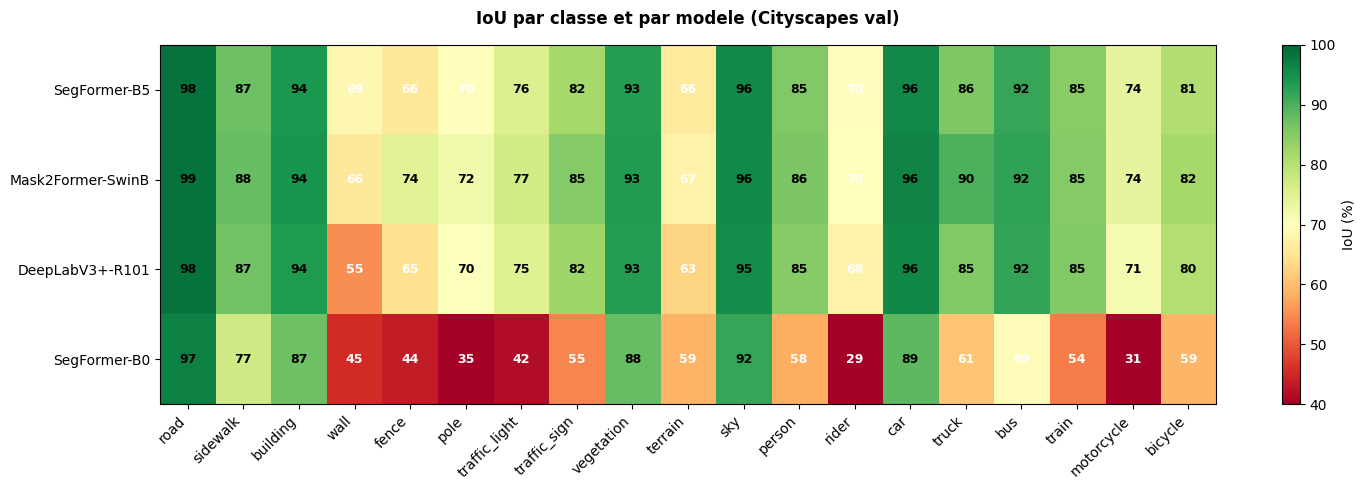

In [11]:
import matplotlib.pyplot as plt


iou_columns = [f"IoU_{label}" for label in CITYSCAPES_LABELS]
iou_matrix = results_df[iou_columns].values  

# Heatmap
fig, ax = plt.subplots(figsize=(15, 5))
im = ax.imshow(iou_matrix, aspect="auto", cmap="RdYlGn", vmin=40, vmax=100)

# Annotations dans les cellules
for i in range(iou_matrix.shape[0]):
    for j in range(iou_matrix.shape[1]):
        val = iou_matrix[i, j]
        ax.text(j, i, f"{val:.0f}", ha="center", va="center",
                color="black" if val > 70 else "white", fontsize=9, fontweight="bold")

ax.set_xticks(range(len(CITYSCAPES_LABELS)))
ax.set_xticklabels(CITYSCAPES_LABELS, rotation=45, ha="right")
ax.set_yticks(range(len(results_df.index)))
ax.set_yticklabels(results_df.index)
ax.set_title("IoU par classe et par modele (Cityscapes val)",
             fontweight="bold", fontsize=12, pad=15)
plt.colorbar(im, ax=ax, label="IoU (%)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "iou_per_class_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

## SegFormer-B5 vs Mask2Former


In [12]:
def per_image_miou(model_name, rgb_paths, gt_paths, model_cfg=None, is_hf=False):
    """Calcule la mIoU pour CHAQUE image individuellement."""
    if is_hf:
        from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor
        model = SegformerForSemanticSegmentation.from_pretrained(HF_CHECKPOINT).to("cuda:0").eval()
        proc = SegformerImageProcessor.from_pretrained(HF_CHECKPOINT)
    else:
        from mmseg.apis import init_model, inference_model
        model = init_model(str(model_cfg["config"]), str(model_cfg["checkpoint"]), device="cuda:0")

    mious = []
    for rgb_path, gt_path in zip(rgb_paths, gt_paths):
        if is_hf:
            image = Image.open(rgb_path).convert("RGB")
            inputs = proc(images=image, return_tensors="pt").to("cuda:0")
            with torch.no_grad():
                logits = model(**inputs).logits
                upsampled = F.interpolate(
                    logits, size=(image.size[1], image.size[0]),
                    mode="bilinear", align_corners=False,
                ) 
                pred = upsampled.argmax(dim=1)[0].cpu().numpy().astype(np.uint8)
        else:
            result = inference_model(model, str(rgb_path))
            pred = result.pred_sem_seg.data[0].cpu().numpy().astype(np.uint8)

        gt = np.array(Image.open(gt_path))
        h = fast_hist(pred, gt)
        mious.append(per_class_iu(h).mean())

    del model
    torch.cuda.empty_cache()
    return np.array(mious)


mious_b5 = per_image_miou("B5", rgb_paths, gt_paths,
                          model_cfg=MMSEG_CONFIG["SegFormer-B5"])
print(f"B5 : {len(mious_b5)} mesures, mIoU moyen = {mious_b5.mean()*100:.2f}%")

mious_m2f = per_image_miou("M2F", rgb_paths, gt_paths,
                           model_cfg=MMSEG_CONFIG["Mask2Former-SwinB"])
print(f"M2F : {len(mious_m2f)} mesures, mIoU moyen = {mious_m2f.mean()*100:.2f}%")

Calcul mIoU par image pour B5 et Mask2Former (test statistique)...
Cela prend ~30 min supplementaires sur RTX 2060.



C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\models\builder.py:36: UserWarning: ``build_loss`` would be deprecated soon, please use ``mmseg.registry.MODELS.build()`` 
  warnings.warn('``build_loss`` would be deprecated soon, please use '
C:\Users\youss\miniconda3\envs\coolpath\lib\site-packages\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(


Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\checkpoints\segformer_mit-b5_8x1_1024x1024_160k_cityscapes_20211206_072934-87a052ec.pth
B5 : 500 mesures, mIoU moyen = 47.50%
Loads checkpoint by local backend from path: C:\Users\youss\Downloads\coolpath_local\checkpoints\mask2former_swin-b-in22k-384x384-pre_8xb2-90k_cityscapes-512x1024_20221203_045030-9a86a225.pth
M2F : 500 mesures, mIoU moyen = 48.85%


In [13]:
from scipy import stats

# Test t apparie : H0 = "B5 et M2F ont la meme mIoU"
diff = mious_b5 - mious_m2f
t_stat, p_value = stats.ttest_rel(mious_b5, mious_m2f)

print("=== Test statistique : SegFormer-B5 vs Mask2Former-SwinB ===\n")
print(f"  N images               : {len(diff)}")
print(f"  mIoU moyen B5          : {mious_b5.mean()*100:.2f}%")
print(f"  mIoU moyen M2F         : {mious_m2f.mean()*100:.2f}%")
print(f"  Difference moyenne     : {diff.mean()*100:+.2f}%")
print(f"  Ecart-type difference  : {diff.std()*100:.2f}%")
print(f"  Statistique t          : {t_stat:.3f}")
print(f"  p-value                : {p_value:.4e}")
print()

if p_value < 0.05:
    winner = "SegFormer-B5" if diff.mean() > 0 else "Mask2Former-SwinB"
    print(f"  Conclusion : difference STATISTIQUEMENT SIGNIFICATIVE (p < 0.05)")
    print(f"  -> {winner} est le meilleur sur Cityscapes val")
else:
    print(f"  Conclusion : difference NON significative (p >= 0.05)")
    print(f"  -> Les 2 modeles sont equivalents sur Cityscapes val")

# Sauvegarde
stat_results = pd.DataFrame({
    "model": ["SegFormer-B5", "Mask2Former-SwinB"],
    "miou_mean": [mious_b5.mean(), mious_m2f.mean()],
    "miou_std": [mious_b5.std(), mious_m2f.std()],
})
stat_results.to_csv(OUTPUT_DIR / "stat_test_b5_vs_m2f.csv", index=False)
print(f"\nResultats sauvegardes : {OUTPUT_DIR / 'stat_test_b5_vs_m2f.csv'}")

=== Test statistique : SegFormer-B5 vs Mask2Former-SwinB ===

  N images               : 500
  mIoU moyen B5          : 47.50%
  mIoU moyen M2F         : 48.85%
  Difference moyenne     : -1.36%
  Ecart-type difference  : 2.54%
  Statistique t          : -11.928
  p-value                : 4.9461e-29

  Conclusion : difference STATISTIQUEMENT SIGNIFICATIVE (p < 0.05)
  -> Mask2Former-SwinB est le meilleur sur Cityscapes val

Resultats sauvegardes : C:\Users\youss\Downloads\coolpath_local\data\outputs\cityscapes_eval\stat_test_b5_vs_m2f.csv


## 12. Visualisation distribution mIoU par image

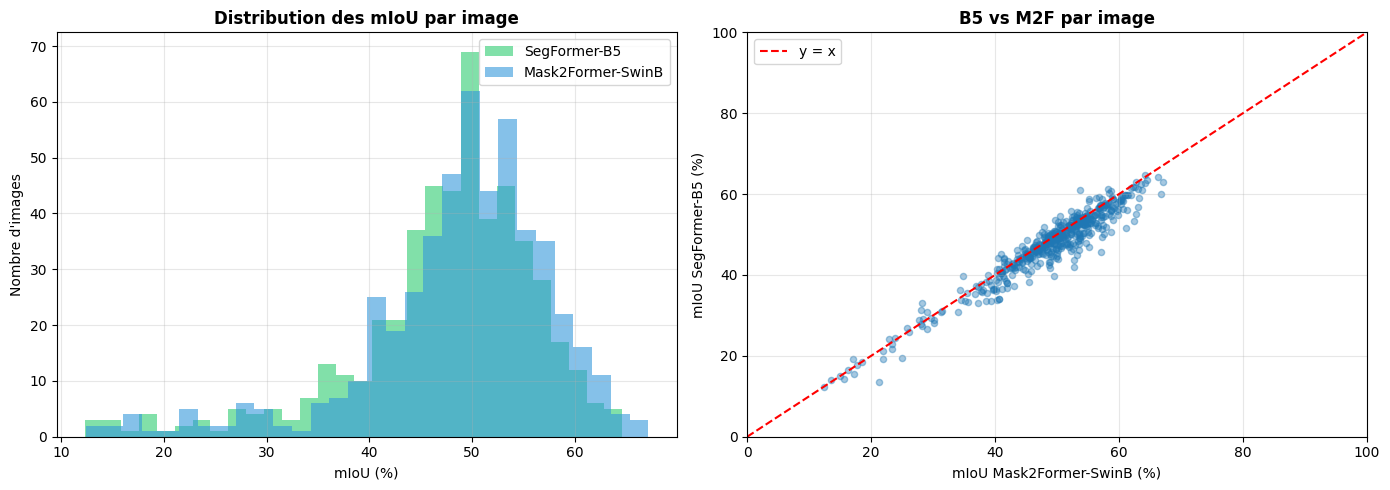

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogrammes
axes[0].hist(mious_b5 * 100, bins=30, alpha=0.6, label="SegFormer-B5", color="#2ecc71")
axes[0].hist(mious_m2f * 100, bins=30, alpha=0.6, label="Mask2Former-SwinB", color="#3498db")
axes[0].set_xlabel("mIoU (%)")
axes[0].set_ylabel("Nombre d'images")
axes[0].set_title("Distribution des mIoU par image", fontweight="bold")
axes[0].legend()
axes[0].grid(alpha=0.3)

# Scatter B5 vs M2F (1 point = 1 image)
axes[1].scatter(mious_m2f * 100, mious_b5 * 100, alpha=0.4, s=20)
axes[1].plot([0, 100], [0, 100], "r--", label="y = x")
axes[1].set_xlabel("mIoU Mask2Former-SwinB (%)")
axes[1].set_ylabel("mIoU SegFormer-B5 (%)")
axes[1].set_title("B5 vs M2F par image", fontweight="bold")
axes[1].legend()
axes[1].grid(alpha=0.3)
axes[1].set_xlim(0, 100)
axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "miou_distribution.png", dpi=110, bbox_inches="tight")
plt.show()

## 13. Graphique récapitulatif final

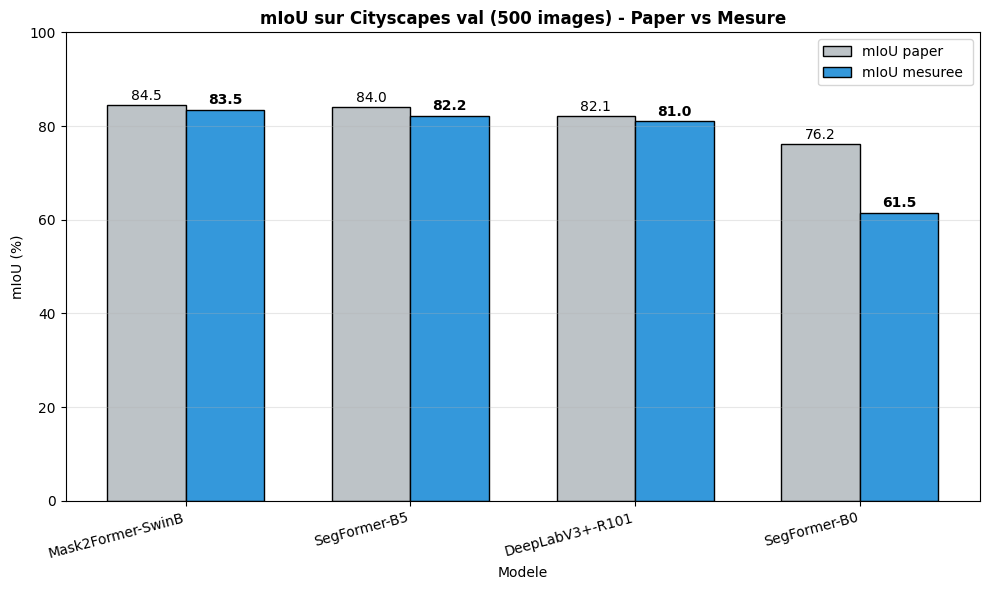

In [16]:
# Barchart mIoU global avec valeurs paper en référence
fig, ax = plt.subplots(figsize=(10, 6))

models = list(summary_main.index)
measured = summary_main["mIoU"].values
paper = [paper_miou[m] for m in models]

x = np.arange(len(models))
width = 0.35
bars1 = ax.bar(x - width/2, paper, width, label="mIoU paper",
               color="#bdc3c7", edgecolor="black")
bars2 = ax.bar(x + width/2, measured, width, label="mIoU mesuree ",
               color="#3498db", edgecolor="black")

# Annotations
for bar, val in zip(bars1, paper):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10)
for bar, val in zip(bars2, measured):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f"{val:.1f}", ha="center", va="bottom", fontsize=10, fontweight="bold")

ax.set_xlabel("Modele")
ax.set_ylabel("mIoU (%)")
ax.set_title(f"mIoU sur Cityscapes val (500 images) - Paper vs Mesure",
             fontweight="bold", fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha="right")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "miou_paper_vs_measured.png", dpi=110, bbox_inches="tight")
plt.show()